### 数据准备
下载cifar10数据集
由于网络问题 转为手动下载 网址[cifar10](https://gitcode.com/open-source-toolkit/94ecd/?utm_source=tools_gitcode&index=top&type=card&&uuid_tt_dd=10_7555513070-1772353432694-750401&isLogin=9&from_id=142888733&from_link=94bec6c10ce9359141dc1dca925a2071)

### 导入库与初始化设备

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 检查CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda


### 加载数据集

In [ ]:
print(f"当前工作目录: {os.getcwd()}")
data_path =  '../data/cifar-10-python'
target_size = 32
batch_size=64
transform = transforms.Compose([
transforms.ToTensor(), # 将PIL.Image或ndarray转换为Tensor
transforms.Resize(target_size + 4),       # 先放大尺寸
transforms.CenterCrop(target_size), ])     # 再中心裁剪  
# 下载训练集数据，并对数据进如上处理
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
# 把训练集数据载入内存
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
# 下载测试集数据，并对|数据进行如上处理
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)
# 把训练集数据载入内存
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


当前工作目录: e:\mybook\junior\course\机器学习\exp


### 读取并可视化数据集

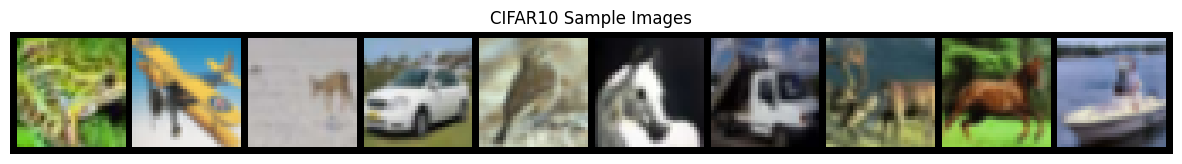

In [3]:
# 获取一个批次数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 选择前10张图片并生成网格
selected_images = images[:10]
grid = torchvision.utils.make_grid(selected_images, nrow=10, padding=2)

# 转换为Matplotlib可显示格式
grid_np = grid.numpy().transpose((1, 2, 0))

# 绘制图像
plt.figure(figsize=(15, 2.5))
plt.imshow(grid_np)
plt.axis('off')
plt.title('CIFAR10 Sample Images')
plt.show()


### 数据预处理与归一化
#### 计算均值方差

In [4]:
transform_original = transforms.Compose([
    transforms.ToTensor(),
])
# 加载原始数据集（不进行归一化）
print("加载原始数据集...")
trainset_original = torchvision.datasets.CIFAR10(root=data_path, train=True, 
                                            download=False, transform=transform_original)
trainloader_original = torch.utils.data.DataLoader(trainset_original, batch_size=batch_size, 
                                              shuffle=False, num_workers=2)
def calculate_mean_std(dataloader):
    """计算数据集的均值和标准差"""
    mean = 0.
    std = 0.
    total_images = 0
    
    for images, _ in dataloader:
        # images shape: [batch_size, channels, height, width]
        batch_samples = images.size(0)
        # 将图片展平为 [batch_size, channels, height*width]
        images = images.view(batch_samples, images.size(1), -1)
        # 计算batch的均值和标准差
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_samples
    
    mean /= total_images
    std /= total_images
    
    return mean, std

# 计算训练集的均值和标准差
mean, std = calculate_mean_std(trainloader_original)

加载原始数据集...


#### 减去该均值，然后再对减去均值之后的数据进行z-score归一化处理

In [5]:
# 减去均值（不进行缩放）
transform_subtract_mean = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=[1.0, 1.0, 1.0])  # 只减去均值，不除以标准差
])

# Z-score归一化（减去均值后除以标准差）
transform_zscore = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

# 重新加载数据集（使用不同的变换）
trainset_subtract_mean = torchvision.datasets.CIFAR10(root=data_path, train=True, 
                                                     download=False, transform=transform_subtract_mean)
trainset_zscore = torchvision.datasets.CIFAR10(root=data_path, train=True, 
                                              download=False, transform=transform_zscore)

# 创建数据加载器
trainloader_subtract_mean = torch.utils.data.DataLoader(trainset_subtract_mean, batch_size=batch_size, 
                                                        shuffle=True, num_workers=2)
trainloader_zscore = torch.utils.data.DataLoader(trainset_zscore, batch_size=batch_size, 
                                                 shuffle=True, num_workers=2)

#### 选取指定编号的数据，把原数据，减去均值后的数据和归一化之后的数据打印在一张图片里。


选取第 40 张图片进行展示
图片类别: dog


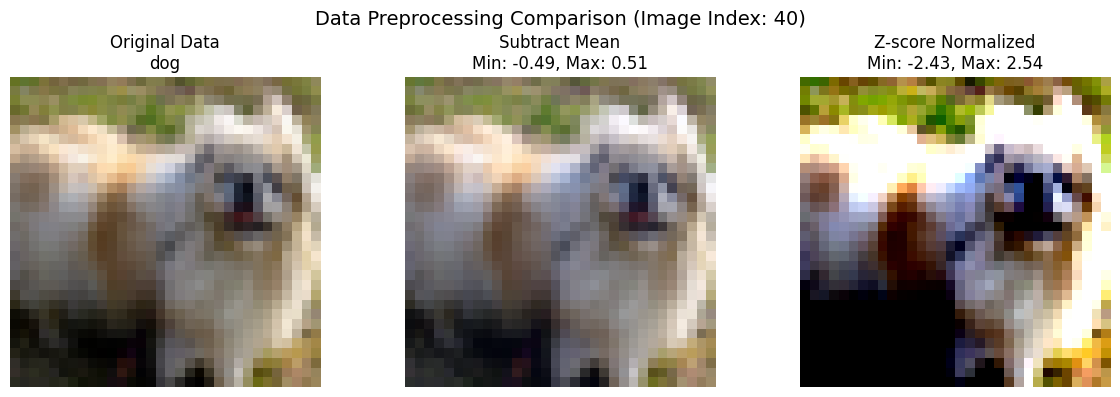

In [6]:
selected_index = 40  # 选择第42张图片

print(f"\n选取第 {selected_index} 张图片进行展示")

# 获取指定索引的图片
original_img, label = trainset_original[selected_index]
subtract_mean_img, _ = trainset_subtract_mean[selected_index]
zscore_img, _ = trainset_zscore[selected_index]

# CIFAR-10 类别名称
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"图片类别: {classes[label]}")

# 4. 将三种处理后的数据显示在一张图片里
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 显示原始数据
img_original = original_img.numpy().transpose((1, 2, 0))
axes[0].imshow(img_original)
axes[0].set_title(f'Original Data\n{classes[label]}')
axes[0].axis('off')

# 显示减去均值后的数据
img_subtract_mean = subtract_mean_img.numpy().transpose((1, 2, 0))
# 减去均值后的数据范围可能在[-0.5, 0.5]左右，需要调整显示范围
img_subtract_mean_display = np.clip(img_subtract_mean + 0.5, 0, 1)  # 调整到[0,1]范围显示
axes[1].imshow(img_subtract_mean_display)
axes[1].set_title(f'Subtract Mean\nMin: {img_subtract_mean.min():.2f}, Max: {img_subtract_mean.max():.2f}')
axes[1].axis('off')

# 显示Z-score归一化后的数据
img_zscore = zscore_img.numpy().transpose((1, 2, 0))
# Z-score归一化后的数据范围更广，需要调整显示范围
img_zscore_display = np.clip(img_zscore * 0.5 + 0.5, 0, 1)  # 调整到[0,1]范围显示
axes[2].imshow(img_zscore_display)
axes[2].set_title(f'Z-score Normalized\nMin: {img_zscore.min():.2f}, Max: {img_zscore.max():.2f}')
axes[2].axis('off')

plt.suptitle(f'Data Preprocessing Comparison (Image Index: {selected_index})', fontsize=14)
plt.tight_layout()
plt.show()

### 数据增强
#### 定义变换

In [7]:
# 定义不同的图像变换
transform_rotate = transforms.Compose([
    transforms.RandomRotation(30),
])

transform_flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
])

transform_crop = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
])

def add_noise(tensor, noise_level=0.1):
    """添加高斯噪声"""
    noise = torch.randn(tensor.size()) * noise_level
    return torch.clamp(tensor + noise, 0, 1)

#### 定义处理函数

In [8]:
def process_images_with_augmentation(dataset, indices, save_path='cifar10_augmentations.png'):
    """
    灵活的图像增强处理函数
    
    参数:
        testset: CIFAR10数据集
        indices: 可以是整数、列表、切片等
        save_path: 保存图片的路径
    """
    # 处理索引，使其统一为列表
    if isinstance(indices, int):
        indices = [indices]
    elif isinstance(indices, slice):
        # 处理切片，如 [0:10] 或 [::2]
        start = indices.start if indices.start is not None else 0
        stop = indices.stop if indices.stop is not None else len(dataset)
        step = indices.step if indices.step is not None else 1
        indices = list(range(start, stop, step))
    elif isinstance(indices, list):
        indices = indices
    elif isinstance(indices, tuple):
        indices = list(indices)
    else:
        raise ValueError(f"不支持的索引类型: {type(indices)}")
    
    # 确保索引不超过数据集大小
    indices = [i for i in indices if i < len(dataset)]
    
    if not indices:
        print("没有有效的索引！")
        return
    
    n_images = len(indices)
    print(f"处理 {n_images} 张图片，索引: {indices}")
    
    # 创建大图画布
    fig, axs = plt.subplots(n_images, 5, figsize=(15, 3 * n_images))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    # 如果只有一张图片，axs需要转换为2D数组
    if n_images == 1:
        axs = axs.reshape(1, -1)
    
    # 处理并绘制每个图像
    for row, idx in enumerate(indices):
        # 获取原始图像
        original_img, label = testset[idx]
        
        # 原始图像
        original_np = original_img.numpy().transpose((1, 2, 0))
        axs[row, 0].imshow(original_np)
        axs[row, 0].set_title(f"Original\nIdx: {idx}, Class: {label}", fontsize=8)
        
        # 旋转后的图像
        rotated_img = transform_rotate(original_img)
        rotated_np = rotated_img.numpy().transpose((1, 2, 0))
        axs[row, 1].imshow(rotated_np)
        axs[row, 1].set_title("Rotated", fontsize=8)
        
        # 翻转后的图像
        flipped_img = transform_flip(original_img)
        flipped_np = flipped_img.numpy().transpose((1, 2, 0))
        axs[row, 2].imshow(flipped_np)
        axs[row, 2].set_title("Flipped", fontsize=8)
        
        # 裁剪后的图像
        cropped_img = transform_crop(original_img)
        cropped_np = cropped_img.numpy().transpose((1, 2, 0))
        axs[row, 3].imshow(cropped_np)
        axs[row, 3].set_title("Cropped", fontsize=8)
        
        # 加噪声后的图像
        noisy_img = add_noise(original_img, noise_level=0.1)
        noisy_np = noisy_img.numpy().transpose((1, 2, 0))
        axs[row, 4].imshow(noisy_np)
        axs[row, 4].set_title("Noisy", fontsize=8)
        
        # 关闭当前行的坐标轴
        for col in range(5):
            axs[row, col].axis('off')
    
    plt.suptitle(f'CIFAR-10 Data Augmentation (Total: {n_images} images)', fontsize=14)
    plt.tight_layout()
    plt.show()

#### 示例测试

处理 5 张图片，索引: [0, 2, 4, 6, 8]


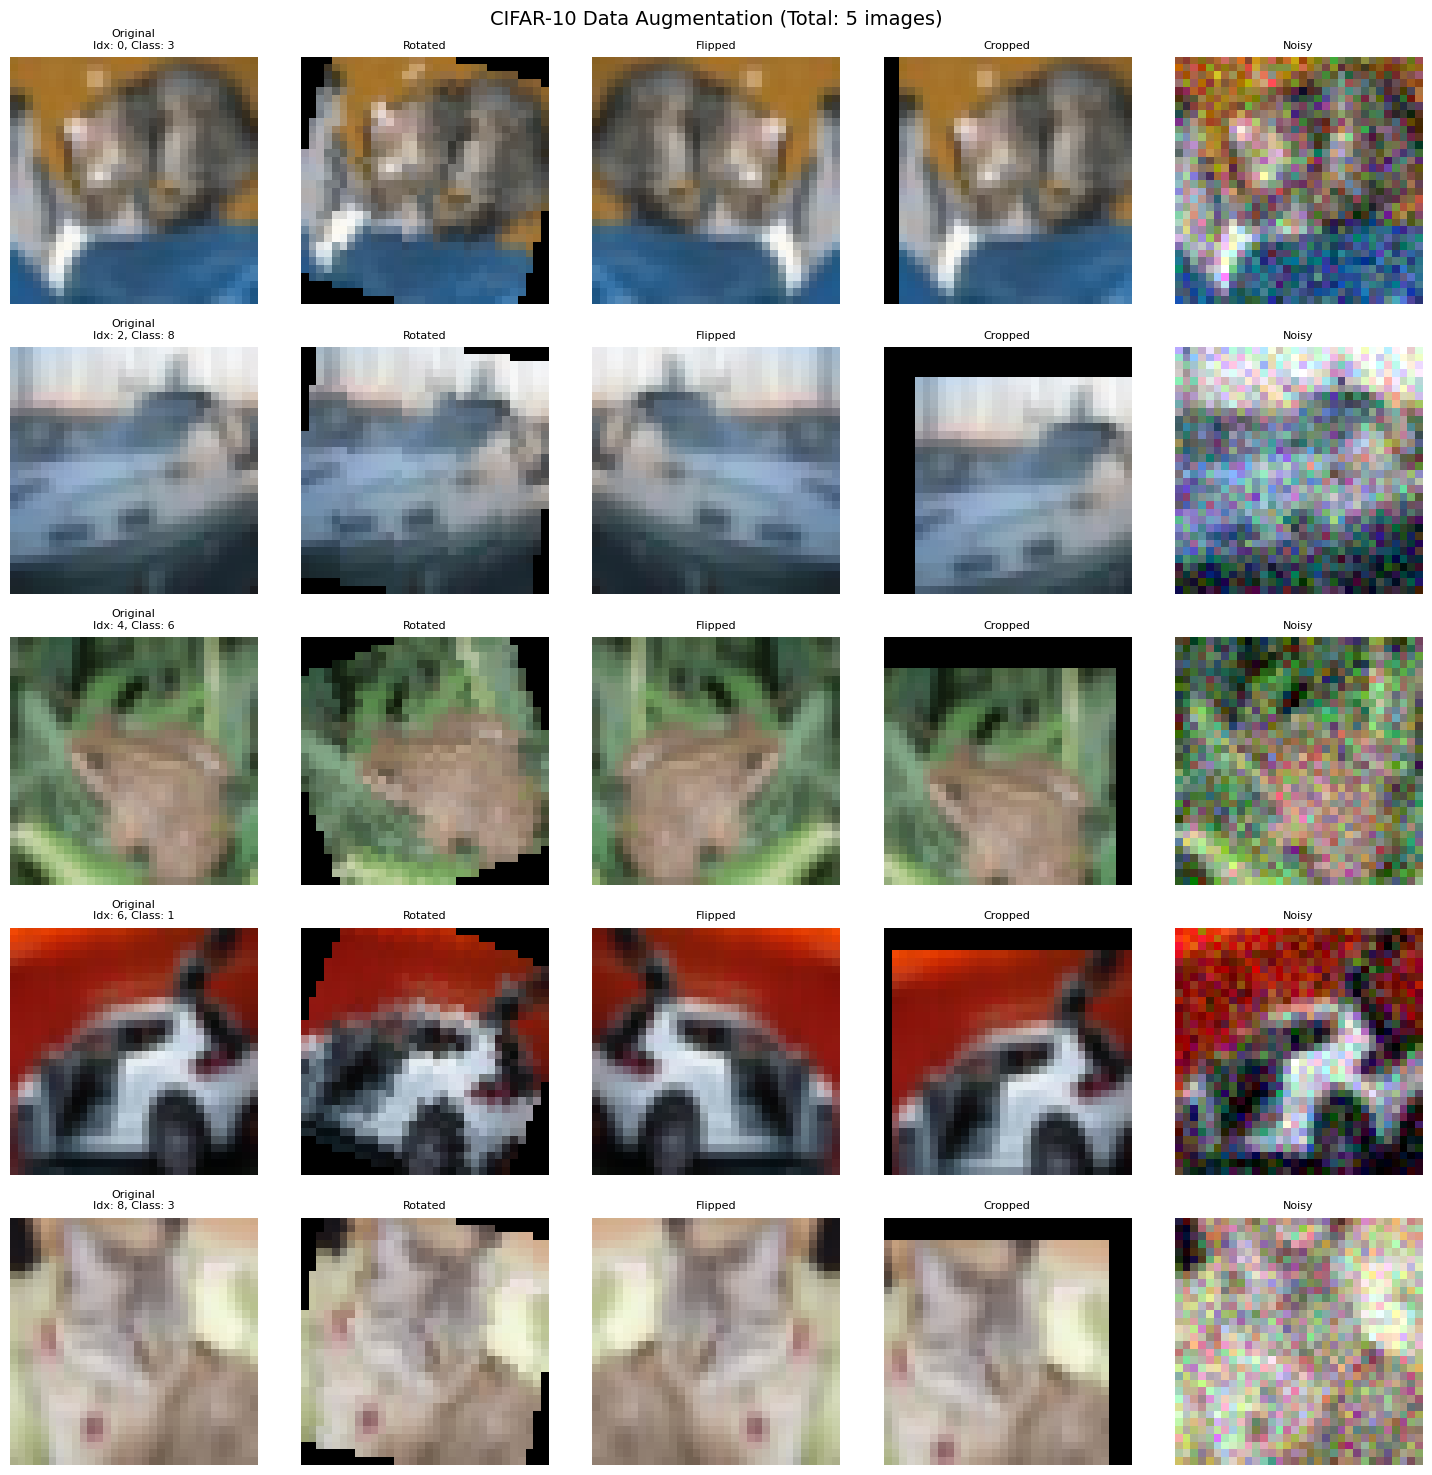

In [9]:
process_images_with_augmentation(trainset_original, slice(0,10,2), 'cifar10_augmentations_1.png')